In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 4)

In [2]:
train = pd.read_parquet('../data/splits/train.parquet')
val   = pd.read_parquet('../data/splits/val.parquet')
test  = pd.read_parquet('../data/splits/test.parquet')
full  = pd.concat([train, val, test], ignore_index=True)

print(f"Train: {len(train):,} rows  ({train['datetime'].min().date()} → {train['datetime'].max().date()})")
print(f"Val:   {len(val):,}  rows  ({val['datetime'].min().date()} → {val['datetime'].max().date()})")
print(f"Test:  {len(test):,}  rows  ({test['datetime'].min().date()} → {test['datetime'].max().date()})")
print(f"\nColumns: {list(full.columns)}")
print(f"\nNaN counts:\n{full.isnull().sum()}")

Train: 21,028 rows  (2011-01-04 → 2022-12-30)
Val:   1,744  rows  (2023-01-03 → 2023-12-29)
Test:  2,469  rows  (2024-01-02 → 2025-05-30)

Columns: ['datetime', 'open', 'low', 'high', 'close', 'volume', 'return_1h', 'return_4h', 'return_24h', 'is_first_bar', 'vol_24h', 'vol_60h', 'volume_ratio', 'rsi_14', 'macd', 'macd_signal', 'macd_diff', 'bb_upper', 'bb_lower', 'bb_width', 'vix_log', 'vix_change_1h']

NaN counts:
datetime         0
open             0
low              0
high             0
close            0
volume           0
return_1h        0
return_4h        0
return_24h       0
is_first_bar     0
vol_24h          0
vol_60h          0
volume_ratio     0
rsi_14           0
macd             0
macd_signal      0
macd_diff        0
bb_upper         0
bb_lower         0
bb_width         0
vix_log          0
vix_change_1h    0
dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train['return_1h'].hist(bins=120, ax=axes[0], edgecolor='none')
axes[0].set_title('return_1h distribution (train)')
axes[0].set_xlabel('return_1h')
axes[0].set_ylabel('count')

stats.probplot(train['return_1h'], plot=axes[1])
axes[1].set_title('QQ-plot: return_1h vs Normal')

plt.tight_layout()
plt.show()

desc = train['return_1h'].describe()
print(desc.to_string())
print(f"\nSkewness : {train['return_1h'].skew():.4f}")
print(f"Kurtosis : {train['return_1h'].kurtosis():.4f}")

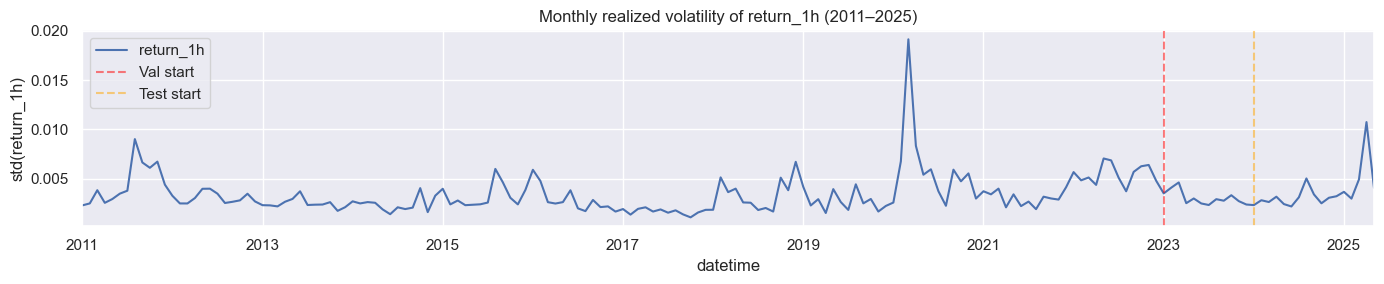

In [4]:
monthly_vol = (
    full.set_index('datetime')['return_1h']
    .resample('ME')
    .std()
)

fig, ax = plt.subplots(figsize=(14, 3))
monthly_vol.plot(ax=ax)
ax.set_title('Monthly realized volatility of return_1h (2011–2025)')
ax.set_ylabel('std(return_1h)')
ax.axvline(pd.Timestamp('2023-01-01'), color='red', linestyle='--', alpha=0.5, label='Val start')
ax.axvline(pd.Timestamp('2024-01-01'), color='orange', linestyle='--', alpha=0.5, label='Test start')
ax.legend()
plt.tight_layout()
plt.show()

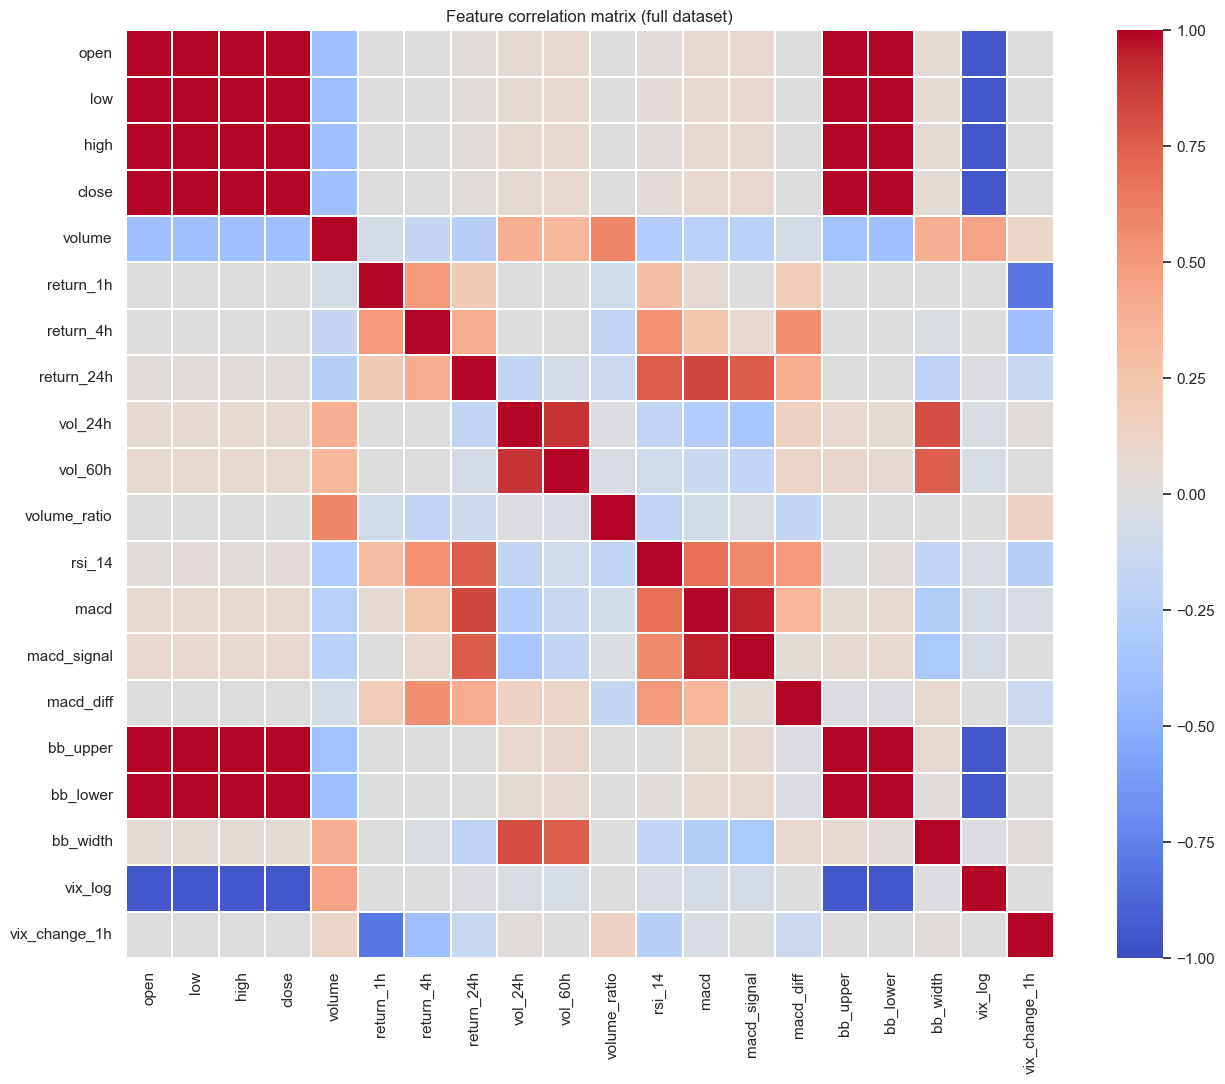

Top correlates with return_1h:
vix_change_1h    0.801116
return_4h        0.499150
rsi_14           0.291946
return_24h       0.195320
macd_diff        0.174726
volume_ratio     0.095814
volume           0.070764
macd             0.056288
vol_60h          0.006990
close            0.005732
Name: return_1h, dtype: float64


In [5]:
num_cols = [c for c in full.columns if c not in ['datetime', 'is_first_bar']]
corr = full[num_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.3, square=True)
plt.title('Feature correlation matrix (full dataset)')
plt.tight_layout()
plt.show()

# Top correlates with target
print("Top correlates with return_1h:")
print(corr['return_1h'].drop('return_1h').abs().sort_values(ascending=False).head(10))

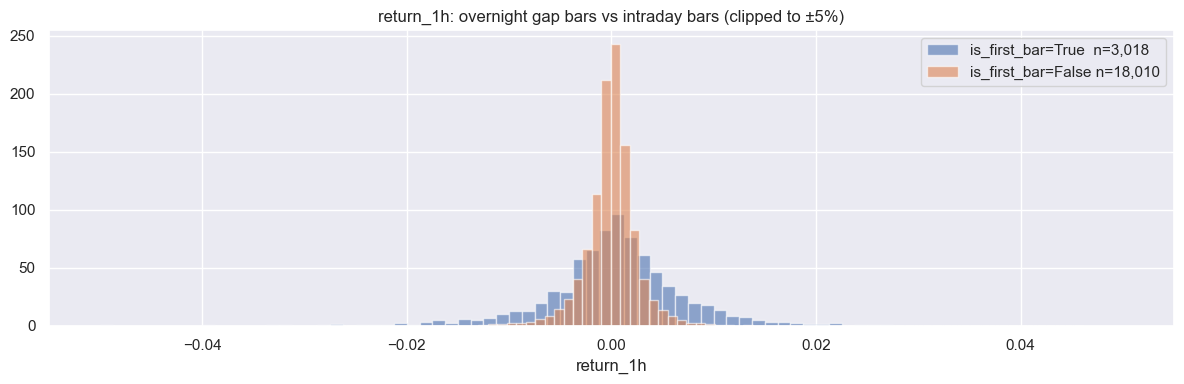

is_first_bar=True  — mean=0.00033  std=0.00784
is_first_bar=False — mean=0.00001  std=0.00287


In [6]:
first = train[train['is_first_bar']]['return_1h']
other = train[~train['is_first_bar']]['return_1h']

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(first.clip(-0.05, 0.05), bins=80, alpha=0.6, density=True,
        label=f'is_first_bar=True  n={len(first):,}')
ax.hist(other.clip(-0.05, 0.05), bins=80, alpha=0.6, density=True,
        label=f'is_first_bar=False n={len(other):,}')
ax.legend()
ax.set_title('return_1h: overnight gap bars vs intraday bars (clipped to ±5%)')
ax.set_xlabel('return_1h')
plt.tight_layout()
plt.show()

print(f"is_first_bar=True  — mean={first.mean():.5f}  std={first.std():.5f}")
print(f"is_first_bar=False — mean={other.mean():.5f}  std={other.std():.5f}")

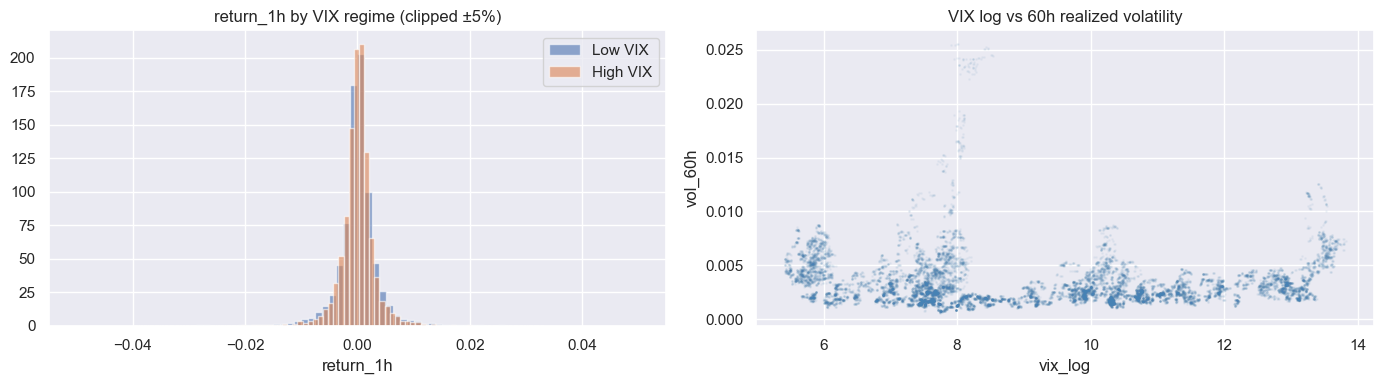

Low VIX  (vix_log ≤ 8.74) — std(return_1h): 0.00452
High VIX (vix_log > 8.74) — std(return_1h): 0.00337


In [7]:
median_vix = train['vix_log'].median()
low_mask  = train['vix_log'] <= median_vix
high_mask = train['vix_log'] > median_vix

low_ret  = train.loc[low_mask,  'return_1h']
high_ret = train.loc[high_mask, 'return_1h']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(low_ret.clip(-0.05, 0.05),  bins=80, alpha=0.6, density=True, label='Low VIX')
axes[0].hist(high_ret.clip(-0.05, 0.05), bins=80, alpha=0.6, density=True, label='High VIX')
axes[0].legend()
axes[0].set_title('return_1h by VIX regime (clipped ±5%)')
axes[0].set_xlabel('return_1h')

axes[1].scatter(train['vix_log'], train['vol_60h'], alpha=0.05, s=1, color='steelblue')
axes[1].set_xlabel('vix_log')
axes[1].set_ylabel('vol_60h')
axes[1].set_title('VIX log vs 60h realized volatility')

plt.tight_layout()
plt.show()

print(f"Low VIX  (vix_log ≤ {median_vix:.2f}) — std(return_1h): {low_ret.std():.5f}")
print(f"High VIX (vix_log > {median_vix:.2f}) — std(return_1h): {high_ret.std():.5f}")